In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import ClassifierChain
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (
    classification_report, f1_score,
    roc_auc_score, precision_recall_curve,
    ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import joblib

BLUE = '#4CBBF0'
RED  = '#F06A6A'
GREEN = '#6BCB77'



#  4.1  CHARGEMENT DES DONNÉES

In [2]:
df = pd.read_csv("diabetic_data_after_FE.csv")

target_cols = ['readmitted_bin', 'change_bin']

X = df.drop(columns=target_cols)
y = df[target_cols]

print("Dimensions X :", X.shape)
print("Dimensions y :", y.shape)
print(f"Positifs readmitted_bin : {y['readmitted_bin'].mean()*100:.1f}%")
print(f"Positifs change_bin     : {y['change_bin'].mean()*100:.1f}%")

Dimensions X : (101763, 54)
Dimensions y : (101763, 2)
Positifs readmitted_bin : 11.2%
Positifs change_bin     : 46.2%


#  4.2  SÉPARATION TRAIN / TEST
80% entraînement / 20% test
stratify sur readmitted_bin pour conserver le ratio de classes
dans les deux splits (important car ~11% de positifs seulement).

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y['readmitted_bin']
)

print(f"\nTrain : {X_train.shape[0]:,} lignes")
print(f"Test  : {X_test.shape[0]:,} lignes")


Train : 81,410 lignes
Test  : 20,353 lignes


#  4.3  MODÉLISATION — ClassifierChain

Pourquoi ClassifierChain ?
  On a deux cibles liées : readmitted_bin et change_bin.
  ClassifierChain entraîne un modèle par cible en chaîne :
    + modèle 1 : prédit readmitted_bin
    + modèle 2 : prédit change_bin EN utilisant la prédiction de readmitted_bin
  Cela capture la dépendance entre les deux cibles.

Trois modèles comparés :
  1. Random Forest   — robuste, peu de réglages nécessaires
  2. XGBoost         — gradient boosting, très performant
  3. LightGBM        — gradient boosting rapide, bon sur grands datasets



In [ ]:
# Calcul du ratio déséquilibre pour XGBoost
ratio = (y_train['readmitted_bin'] == 0).sum() / (y_train['readmitted_bin'] == 1).sum()

modeles = {
    'RandomForest': ClassifierChain(
        base_estimator=RandomForestClassifier(
            n_estimators=200,
            max_depth=12,
            class_weight='balanced_subsample',
            random_state=42,
            n_jobs=-1
        )
    ),
    'XGBoost': ClassifierChain(
        base_estimator=XGBClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.05,
            scale_pos_weight=ratio,
            eval_metric='logloss',
            random_state=42,
            n_jobs=-1
        )
    ),
    'LightGBM': ClassifierChain(
        base_estimator=LGBMClassifier(
            n_estimators=200,
            max_depth=8,
            learning_rate=0.05,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1,
            verbose=-1
        )
    )
}

resultats = {}

for nom, modele in modeles.items():
    print(f"\nEntraînement {nom}...")
    modele.fit(X_train, y_train)
    resultats[nom] = modele
    print(f"   {nom} terminé.")


Entraînement RandomForest...
   RandomForest terminé.

Entraînement XGBoost...


#  4.4  ÉVALUATION DES MODÈLES
Métriques utilisées :
  - F1-score    : équilibre précision/rappel — adapté aux classes déséquilibrées
  - ROC-AUC     : capacité discriminante du modèle (0.5 = aléatoire, 1 = parfait)
  - Threshold   : seuil optimal trouvé via la courbe Précision-Rappel
  - Matrice de confusion : visualisation des erreurs

Pourquoi optimiser le threshold ?
  + Par défaut, sklearn prédit 1 si proba > 0.5.
  + Avec 11% de positifs, ce seuil est trop élevé → on loupe beaucoup de cas.
  On cherche le seuil qui maximise le F1-score sur la courbe PR.


  MODÈLE : RandomForest

  Cible : readmitted_bin
  Threshold optimal : 0.488
              precision    recall  f1-score   support

           0       0.92      0.75      0.83     18082
           1       0.19      0.48      0.28      2271

    accuracy                           0.72     20353
   macro avg       0.56      0.61      0.55     20353
weighted avg       0.84      0.72      0.77     20353

  F1 Macro : 0.5516
  ROC-AUC  : 0.6675

  Cible : change_bin
  Threshold optimal : 0.437
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     11021
           1       1.00      0.99      0.99      9332

    accuracy                           0.99     20353
   macro avg       0.99      0.99      0.99     20353
weighted avg       0.99      0.99      0.99     20353

  F1 Macro : 0.9931
  ROC-AUC  : 0.9967

  MODÈLE : XGBoost

  Cible : readmitted_bin
  Threshold optimal : 0.548
              precision    recall  f1-score   support

        

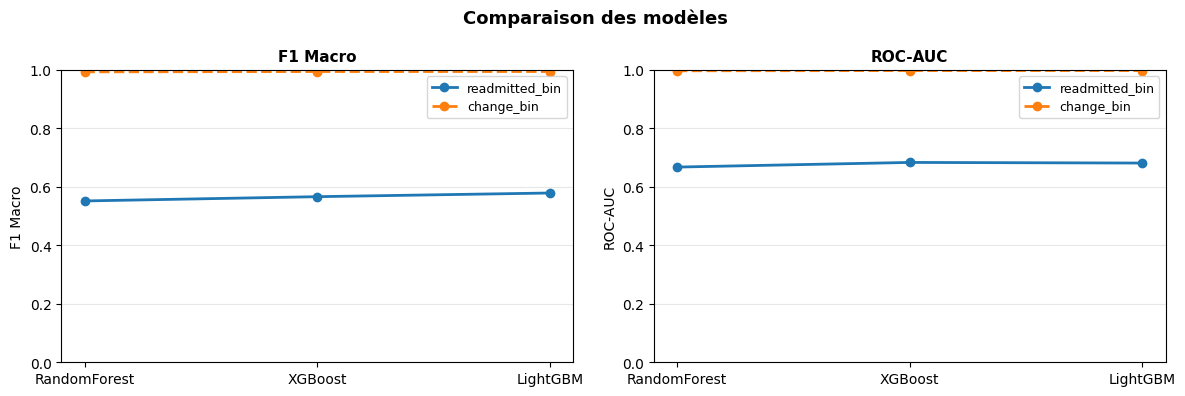


  Meilleur modèle (AUC readmitted) : XGBoost


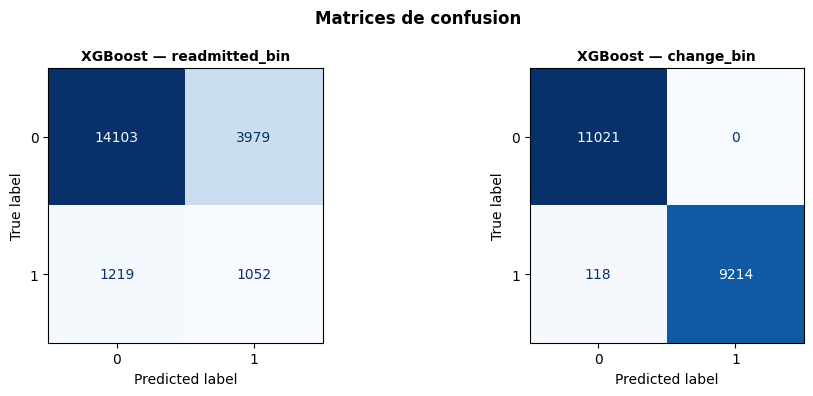

In [5]:
def evaluer_modele(nom, modele, X_test, y_test, target_cols):
    """Évalue un modèle ClassifierChain et affiche les résultats."""

    probas = modele.predict_proba(X_test)
    scores = {}

    print(f"\n{'='*55}")
    print(f"  MODÈLE : {nom}")
    print(f"{'='*55}")

    for i, target in enumerate(target_cols):

        y_true  = y_test[target]
        y_proba = probas[:, i]

        # Seuil optimal via courbe Précision-Rappel
        precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
        f1_vals  = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-8)
        best_thr = thresholds[np.argmax(f1_vals)]
        y_pred   = (y_proba >= best_thr).astype(int)

        f1  = f1_score(y_true, y_pred, average='macro')
        auc = roc_auc_score(y_true, y_proba)

        scores[target] = {'f1': f1, 'auc': auc, 'threshold': best_thr}

        print(f"\n  Cible : {target}")
        print(f"  Threshold optimal : {best_thr:.3f}")
        print(classification_report(y_true, y_pred))
        print(f"  F1 Macro : {f1:.4f}")
        print(f"  ROC-AUC  : {auc:.4f}")

    return scores


# Évaluation des 3 modèles
tous_les_scores = {}
for nom, modele in resultats.items():
    tous_les_scores[nom] = evaluer_modele(nom, modele, X_test, y_test, target_cols)

#  Tableau comparatif
print(f"\n{'='*55}")
print("  COMPARAISON DES MODÈLES")
print(f"{'='*55}")
print(f"  {'Modèle':<15} | {'F1 readmitted':>13} | {'AUC readmitted':>14} | {'F1 change':>9} | {'AUC change':>10}")
print(f"  {'-'*15}-+-{'-'*13}-+-{'-'*14}-+-{'-'*9}-+-{'-'*10}")
for nom, scores in tous_les_scores.items():
    f1_r  = scores['readmitted_bin']['f1']
    auc_r = scores['readmitted_bin']['auc']
    f1_c  = scores['change_bin']['f1']
    auc_c = scores['change_bin']['auc']
    print(f"  {nom:<15} | {f1_r:>13.4f} | {auc_r:>14.4f} | {f1_c:>9.4f} | {auc_c:>10.4f}")

#  Visualisation comparative
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
noms    = list(tous_les_scores.keys())
metrics = ['f1', 'auc']
titres  = ['F1 Macro', 'ROC-AUC']
colors  = [BLUE, RED, GREEN]

for ax, metric, titre in zip(axes, metrics, titres):
    for target, linestyle in zip(target_cols, ['-', '--']):
        vals = [tous_les_scores[n][target][metric] for n in noms]
        ax.plot(noms, vals, marker='o', linestyle=linestyle, linewidth=2, label=target)
    ax.set_title(titre, fontsize=11, fontweight='bold')
    ax.set_ylabel(titre)
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Comparaison des modèles', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



In [ ]:
# ── Matrices de confusion du meilleur modèle ─────────────────────
# On choisit LightGBM comme modèle de référence pour la visualisation
best_model_name = max(tous_les_scores,
                      key=lambda n: tous_les_scores[n]['readmitted_bin']['auc'])
print(f"\n  Meilleur modèle (AUC readmitted) : {best_model_name}")

best_model = resultats[best_model_name]
probas_best = best_model.predict_proba(X_test)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, (ax, target) in enumerate(zip(axes, target_cols)):
    thr    = tous_les_scores[best_model_name][target]['threshold']
    y_pred = (probas_best[:, i] >= thr).astype(int)
    ConfusionMatrixDisplay.from_predictions(
        y_test[target], y_pred, ax=ax,
        colorbar=False, cmap='Blues'
    )
    ax.set_title(f'{best_model_name} — {target}', fontsize=10, fontweight='bold')

plt.suptitle('Matrices de confusion', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

#  4.5  OPTIMISATION DES HYPERPARAMÈTRES — RandomizedSearchCV

On optimise le meilleur modèle avec RandomizedSearchCV.

Pourquoi RandomizedSearch plutôt que GridSearch ?
  + GridSearch teste TOUTES les combinaisons → très lent sur grands datasets.
   RandomizedSearch tire n_iter combinaisons aléatoires → bien plus rapide,
  résultats comparables en pratique.

On optimise LightGBM qui est le plus rapide à entraîner.
+ Scoring : roc_auc sur readmitted_bin (cible la plus déséquilibrée).


In [ ]:



print(f"\n{'='*55}")
print("  4.5 OPTIMISATION DES HYPERPARAMÈTRES")
print(f"{'='*55}")

param_grid = {
    'base_estimator__n_estimators'  : [100, 200, 300],
    'base_estimator__max_depth'     : [6, 8, 10, 12],
    'base_estimator__learning_rate' : [0.01, 0.05, 0.1],
    'base_estimator__num_leaves'    : [31, 63, 127],
    'base_estimator__min_child_samples': [20, 50, 100],
}

lgbm_chain = ClassifierChain(
    base_estimator=LGBMClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
)

search = RandomizedSearchCV(
    estimator=lgbm_chain,
    param_distributions=param_grid,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("\nLancement de RandomizedSearchCV (20 itérations × 3 folds)...")
search.fit(X_train, y_train)

print(f"\n  Meilleurs hyperparamètres trouvés :")
for param, val in search.best_params_.items():
    print(f"    {param:<45} : {val}")
print(f"\n  Meilleur score CV (ROC-AUC) : {search.best_score_:.4f}")

#  4.6  ÉVALUATION DU MEILLEUR MODÈLE OPTIMISÉ


In [ ]:

print(f"\n{'='*55}")
print("  4.6 ÉVALUATION — MODÈLE OPTIMISÉ")
print(f"{'='*55}")

best_optimized = search.best_estimator_
probas_opt     = best_optimized.predict_proba(X_test)

scores_opt = {}
for i, target in enumerate(target_cols):

    y_true  = y_test[target]
    y_proba = probas_opt[:, i]

    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    f1_vals  = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-8)
    best_thr = thresholds[np.argmax(f1_vals)]
    y_pred   = (y_proba >= best_thr).astype(int)

    f1  = f1_score(y_true, y_pred, average='macro')
    auc = roc_auc_score(y_true, y_proba)
    scores_opt[target] = {'f1': f1, 'auc': auc}

    print(f"\n  Cible : {target}")
    print(f"  Threshold : {best_thr:.3f}")
    print(classification_report(y_true, y_pred))
    print(f"  F1 Macro : {f1:.4f}")
    print(f"  ROC-AUC  : {auc:.4f}")

print(f"\n  GAIN APRÈS OPTIMISATION (LightGBM) :")
print(f"  {'Métrique':<25} | {'Avant':>8} | {'Après':>8} | {'Gain':>8}")
print(f"  {'-'*25}-+-{'-'*8}-+-{'-'*8}-+-{'-'*8}")
for target in target_cols:
    for metric in ['f1', 'auc']:
        avant = tous_les_scores['LightGBM'][target][metric]
        apres = scores_opt[target][metric]
        gain  = apres - avant
        label = f"{target} — {metric.upper()}"
        print(f"  {label:<25} | {avant:>8.4f} | {apres:>8.4f} | {gain:>+8.4f}")



In [ ]:
joblib.dump(best_optimized, 'best_model.pkl')
print(f"\n   Modèle optimisé sauvegardé : best_model.pkl")